All imported Python modules will be placed here for reference:

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

Import the data file.

In [2]:
life_expectancy_data = pd.read_csv('all_data.csv')

Print out the first five rows to ensure data correctly imported.

In [3]:
life_expectancy_data.head()

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


Investigate the data set for missing values:

In [4]:
life_expectancy_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


Having looked at the data types, the only one I may consider altering for clarity would be the year column to a datetime dtype. At the moment however leaving it as an int64 is not going to harm as it is only the year that is recorded in this dtype.

I can also see that there are 96 entries and none of the columns have nil entries, so the data appears to be clean

The data consists of 96 entries with 4 columns headings.

I am now going to check the first two columns fo rtheir unique values as these are our categorical data colums:

In [5]:
countries = life_expectancy_data['Country'].unique()
print(countries)

['Chile' 'China' 'Germany' 'Mexico' 'United States of America' 'Zimbabwe']


In [6]:
years = life_expectancy_data['Year'].unique()
print(years)

[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015]


My first thought is that I am going to look at line plots of Life expectancy and GDP to see if there is a potential correlatiuon between these elements. as there are only 6 countries I think it would be reasonable to plot them all on the same charts. I will make 2 subplots to place the charts side by side.

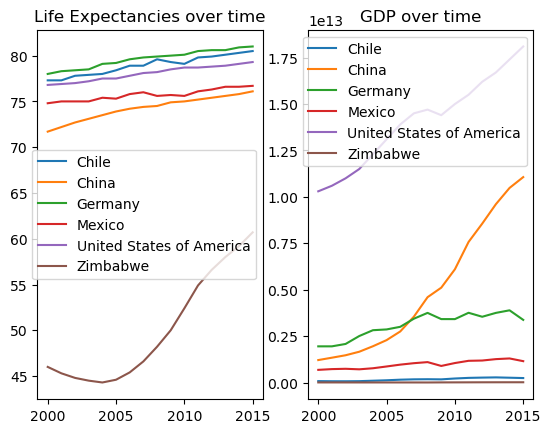

In [7]:
plt.subplot(1,2,1)
for country in countries:
    plt.plot(life_expectancy_data[life_expectancy_data.Country == country]['Year'], 
             life_expectancy_data[life_expectancy_data.Country == country]['Life expectancy at birth (years)'])
    plt.legend(countries)
    plt.title('Life Expectancies over time')

plt.subplot(1,2,2)
for country in countries:
    plt.plot(life_expectancy_data[life_expectancy_data.Country == country]['Year'], 
             life_expectancy_data[life_expectancy_data.Country == country]['GDP'])
    plt.legend(countries)
    plt.title('GDP over time')

Looking at these 2 plots it does not appear to be a correlation between GDP and life expectancy as the second lowest GDP, for Chile, corresponds with the second highest Life expectancies. The highest GDP relates to the third highest Life expectancy, for the USA. The rate of climb in life expectancy in Zimbabwe does not correlate with a similar rise in GDP (in fact Zimbabwe's GDP shows little difference over time), so I am lead to think that there is a different reason for the rise in life expectancy in Zimbabwe than an increase in GDP. Germany who has the highest Life expectancy has the third highest GDP, which further indicates there is no direct correlation between GDP and life expectancy.

What are the means for Life expectancy and GDP over time?

In [8]:
for year in years:
    mean_life_expect = np.sum(life_expectancy_data[life_expectancy_data.Year == year]['Life expectancy at birth (years)']
                          / len(countries))
    print(f'In year {year} the mean life expectancy is: {mean_life_expect}')

In year 2000 the mean life expectancy is: 70.76666666666667
In year 2001 the mean life expectancy is: 70.83333333333333
In year 2002 the mean life expectancy is: 70.95
In year 2003 the mean life expectancy is: 71.03333333333333
In year 2004 the mean life expectancy is: 71.3
In year 2005 the mean life expectancy is: 71.48333333333333
In year 2006 the mean life expectancy is: 71.94999999999999
In year 2007 the mean life expectancy is: 72.3
In year 2008 the mean life expectancy is: 72.66666666666667
In year 2009 the mean life expectancy is: 73.06666666666666
In year 2010 the mean life expectancy is: 73.48333333333333
In year 2011 the mean life expectancy is: 74.2
In year 2012 the mean life expectancy is: 74.60000000000001
In year 2013 the mean life expectancy is: 74.96666666666667
In year 2014 the mean life expectancy is: 75.31666666666666
In year 2015 the mean life expectancy is: 75.71666666666667


We can see from the above that the mean Life expectancy increases over time.

In [9]:
for year in years:
    mean_life_expect = np.sum(life_expectancy_data[life_expectancy_data.Year == year]['GDP']
                          / len(countries))
    print(f'In year {year} the mean GDP is: {mean_life_expect}')

In year 2000 the mean GDP is: 2371583148292.0005
In year 2001 the mean GDP is: 2448751884776.6665
In year 2002 the mean GDP is: 2561221487972.5
In year 2003 the mean GDP is: 2743445841940.0005
In year 2004 the mean GDP is: 2991647331876.3335
In year 2005 the mean GDP is: 3207074369200.0
In year 2006 the mean GDP is: 3463348816083.3335
In year 2007 the mean GDP is: 3785749658350.0005
In year 2008 the mean GDP is: 4055985617133.3335
In year 2009 the mean GDP is: 4000653262268.0
In year 2010 the mean GDP is: 4299586643284.9995
In year 2011 the mean GDP is: 4710965075124.834
In year 2012 the mean GDP is: 4962082415041.999
In year 2013 the mean GDP is: 5269257628109.834
In year 2014 the mean GDP is: 5558058508206.0
In year 2015 the mean GDP is: 5658565444634.5


We can see from this that mean GDP increases over time too, although this still does not explain the increase in Zimbabwe's Life expectancy over time. I do not believe this data set has enough information to be able to attribute a rise in GDP to an increase in Life expectancy. I believe there is another factor at play that the data does not reveal.

I am going to investigate the Zimbabwe data further as this appears to be the anomaly.

In [10]:
zimbabwe_data = life_expectancy_data[life_expectancy_data.Country == 'Zimbabwe']
zimbabwe_data.head(10)

,Country,Year,Life expectancy at birth (years),GDP
80,Zimbabwe,2000,46.0,6.689958e+09
81,Zimbabwe,2001,45.3,6.777385e+09
82,Zimbabwe,2002,44.8,6.342116e+09
83,Zimbabwe,2003,44.5,5.727592e+09
84,Zimbabwe,2004,44.3,5.805598e+09
85,Zimbabwe,2005,44.6,5.755215e+09
86,Zimbabwe,2006,45.4,5.443896e+09
87,Zimbabwe,2007,46.6,5.291950e+09
88,Zimbabwe,2008,48.2,4.415703e+09
89,Zimbabwe,2009,50.0,8.621574e+09


then plot the graphs for GDP and Life expectancy side by side for Zimbabwe's data

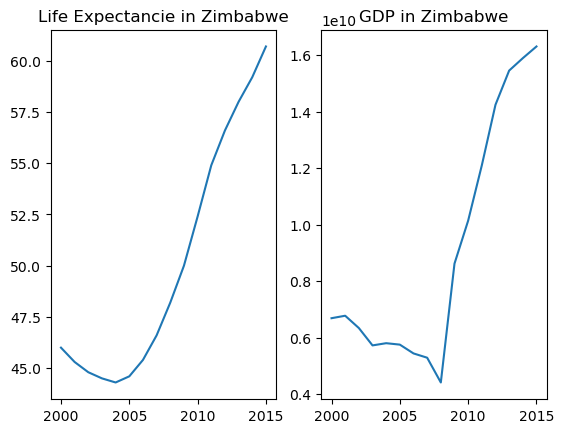

<Figure size 640x480 with 0 Axes>

In [23]:
plt.subplot(1,2,1)
plt.plot(zimbabwe_data.Year, zimbabwe_data['Life expectancy at birth (years)'])
plt.title('Life Expectancie in Zimbabwe')

plt.subplot(1,2,2)
plt.plot(zimbabwe_data.Year, zimbabwe_data.GDP)
plt.title('GDP in Zimbabwe')
plt.show()
plt.clf()

By zooming in on Zimbabwe's data it has become clearer that there does appear to be a correlation between GDP and Life expectancy, that was not revealed in the original data due to scales.

I am going to repeat these graphs for each country. First create the data sets for each individual country:

In [26]:
chile_data = life_expectancy_data[life_expectancy_data.Country == 'Chile']
china_data = life_expectancy_data[life_expectancy_data.Country == 'China']
germany_data = life_expectancy_data[life_expectancy_data.Country == 'Germany']
mexico_data = life_expectancy_data[life_expectancy_data.Country == 'Mexico']
usa_data = life_expectancy_data[life_expectancy_data.Country == 'United States of America']

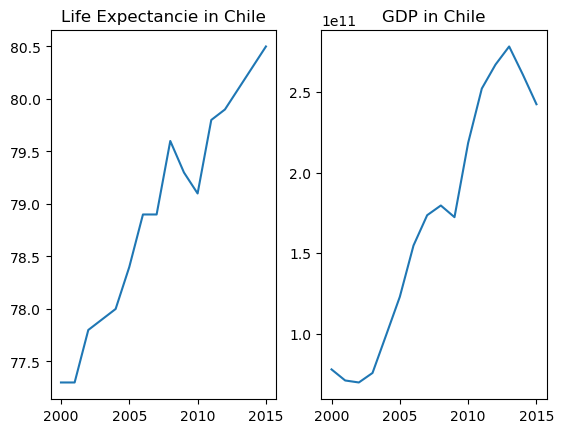

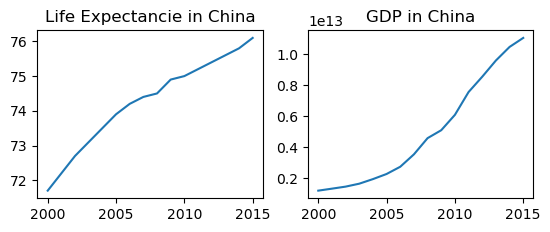

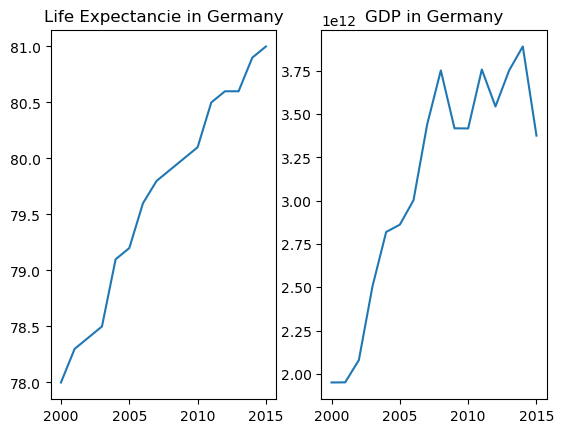

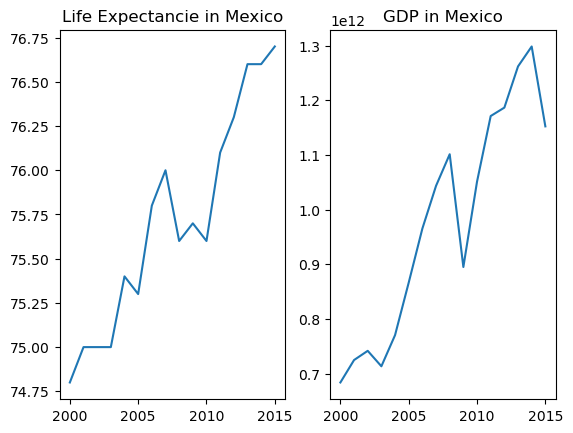

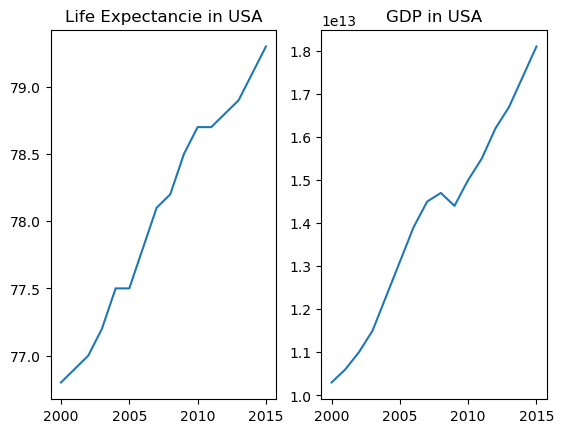

<Figure size 640x480 with 0 Axes>

In [27]:
# Chile
plt.subplot(1,2,1)
plt.plot(chile_data.Year, chile_data['Life expectancy at birth (years)'])
plt.title('Life Expectancie in Chile')
plt.subplot(1,2,2)
plt.plot(chile_data.Year, chile_data.GDP)
plt.title('GDP in Chile')
plt.show()
plt.clf()

# China
plt.subplot(2,2,1)
plt.plot(china_data.Year, china_data['Life expectancy at birth (years)'])
plt.title('Life Expectancie in China')
plt.subplot(2,2,2)
plt.plot(china_data.Year, china_data.GDP)
plt.title('GDP in China')
plt.show()
plt.clf()

# Germany
plt.subplot(1,2,1)
plt.plot(germany_data.Year, germany_data['Life expectancy at birth (years)'])
plt.title('Life Expectancie in Germany')
plt.subplot(1,2,2)
plt.plot(germany_data.Year, germany_data.GDP)
plt.title('GDP in Germany')
plt.show()
plt.clf()

# Mexico
plt.subplot(1,2,1)
plt.plot(mexico_data.Year, mexico_data['Life expectancy at birth (years)'])
plt.title('Life Expectancie in Mexico')
plt.subplot(1,2,2)
plt.plot(mexico_data.Year, mexico_data.GDP)
plt.title('GDP in Mexico')
plt.show()
plt.clf()

# USA
plt.subplot(1,2,1)
plt.plot(usa_data.Year, usa_data['Life expectancy at birth (years)'])
plt.title('Life Expectancie in USA')
plt.subplot(1,2,2)
plt.plot(usa_data.Year, usa_data.GDP)
plt.title('GDP in USA')
plt.show()
plt.clf()

These graphs indicate a correlation between GDP and life expectancy that was not revealed when looking at all the figures in the original graph.